In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sentence_transformers import SentenceTransformer

C:\Users\kaitl\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PARTITIONS_CSV = "TestingData/partitions.csv"   # output of book_partitioner.ipynb

# Genres in a consistent display order
GENRES = ["biography", "fantasy", "horror", "romance", "sci-fi"]

In [3]:
partitions = pd.read_csv(PARTITIONS_CSV)

print(f"Partitions loaded : {len(partitions):,} rows")
print(f"\nGenre distribution:")
print(partitions['genre'].value_counts().to_string())
partitions.head(3)

Partitions loaded : 5,000 rows

Genre distribution:
genre
biography    1000
fantasy      1000
horror       1000
romance      1000
sci-fi       1000


,partition_id,book,genre,start_token,text,word_count
0,AutobiographyOfBenjaminFranklin_partition_a,AutobiographyOfBenjaminFranklin,biography,14592,Boston. I took leave of Keimer as going to see...,400
1,AutobiographyOfBenjaminFranklin_partition_b,AutobiographyOfBenjaminFranklin,biography,3278,translated into all the languages of Europe. I...,400
2,AutobiographyOfBenjaminFranklin_partition_c,AutobiographyOfBenjaminFranklin,biography,36048,"in conversation, which makes his company still...",400


In [4]:
X_text = partitions["text"].tolist()
y      = partitions["genre"].tolist()

# TF-IDF Vectorization
tfidf_vec = TfidfVectorizer(
    max_features=2000, 
    stop_words='english', 
    ngram_range=(1, 2)
)
tfidf_features = tfidf_vec.fit_transform(X_text)

# LDA Features
count_vec = CountVectorizer(max_features=2000, stop_words='english')
raw_counts = count_vec.fit_transform(X_text)

lda_model = LatentDirichletAllocation(
    n_components=5,      # Since we have 5 genres, we look for 5 topics
    random_state=42,
    n_jobs=-1
)
lda_features = lda_model.fit_transform(raw_counts)

# Embeddings
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embedding_features = embedding_model.encode(X_text, show_progress_bar=True)

print(f"TF-IDF shape: {tfidf_features.shape}")
print(f"LDA shape: {lda_features.shape}")
print(f"Embedding shape: {embedding_features.shape}")

Batches: 100%|██████████| 157/157 [02:03<00:00,  1.27it/s]

TF-IDF shape: (5000, 2000)
LDA shape: (5000, 5)
Embedding shape: (5000, 384)


In [5]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, cohen_kappa_score
import pandas as pd
from collections import Counter

def map_clusters_to_labels(y_true, y_pred):
    """
    Maps cluster IDs to the most frequent genre label in that cluster.
    """
    # Convert y_true to a numpy array for easier indexing
    y_true_arr = np.array(y_true)
    
    mapping = {}
    unique_clusters = np.unique(y_pred)
    
    for cluster_id in unique_clusters:
        # Find all actual labels that ended up in this cluster
        mask = (y_pred == cluster_id)
        if sum(mask) == 0: continue
        
        # Get the subset of genre labels in this cluster
        genre_subset = y_true_arr[mask]
        
        # Use Counter instead of scipy.stats.mode
        # most_common(1) returns [(label, count)]
        most_frequent_label = Counter(genre_subset).most_common(1)[0][0]
        mapping[cluster_id] = most_frequent_label
    
    # Create the mapped predictions
    mapped_predictions = [mapping.get(p, "unknown") for p in y_pred]
    return mapped_predictions

# 2. Setup Models and Features
feature_sets = {
    "TF-IDF": tfidf_features,
    "LDA": lda_features,
    "Embeddings": embedding_features
}

models = {
    "K-Means": KMeans(n_clusters=5, random_state=42),
    "EM (GMM)": GaussianMixture(n_components=5, random_state=42),
    "Hierarchical": AgglomerativeClustering(n_clusters=5)
}

# 3. Run Pipeline
results = []

for feature_name, X in feature_sets.items():
    for model_name, model in models.items():
        print(f"Running {model_name} on {feature_name}...")
        
        # Fit model
        X_input = X.toarray() if hasattr(X, "toarray") else X
        
        # Fit model using the new X_input
        # (We use the same logic for all, since we converted X to dense)
        labels = model.fit_predict(X_input)
            
        # Evaluation
        sil_score = silhouette_score(X_input, labels)
        
        # Map labels to genres for Kappa calculation
        mapped_labels = map_clusters_to_labels(y, labels)
        kappa = cohen_kappa_score(y, mapped_labels)
        
        results.append({
            "Feature": feature_name,
            "Algorithm": model_name,
            "Silhouette": sil_score,
            "Kappa": kappa
        })

# 4. Display Results
results_df = pd.DataFrame(results)
print(results_df.to_string())

Running K-Means on TF-IDF...
Running EM (GMM) on TF-IDF...
Running Hierarchical on TF-IDF...
Running K-Means on LDA...
Running EM (GMM) on LDA...
Running Hierarchical on LDA...
Running K-Means on Embeddings...
Running EM (GMM) on Embeddings...
Running Hierarchical on Embeddings...
      Feature     Algorithm  Silhouette    Kappa
0      TF-IDF       K-Means    0.020637  0.32300
1      TF-IDF      EM (GMM)    0.020637  0.32300
2      TF-IDF  Hierarchical    0.025379  0.24925
3         LDA       K-Means    0.512360  0.40125
4         LDA      EM (GMM)    0.055480  0.19625
5         LDA  Hierarchical    0.443552  0.40925
6  Embeddings       K-Means    0.041075  0.61825
7  Embeddings      EM (GMM)    0.041053  0.61975
8  Embeddings  Hierarchical    0.033520  0.62725


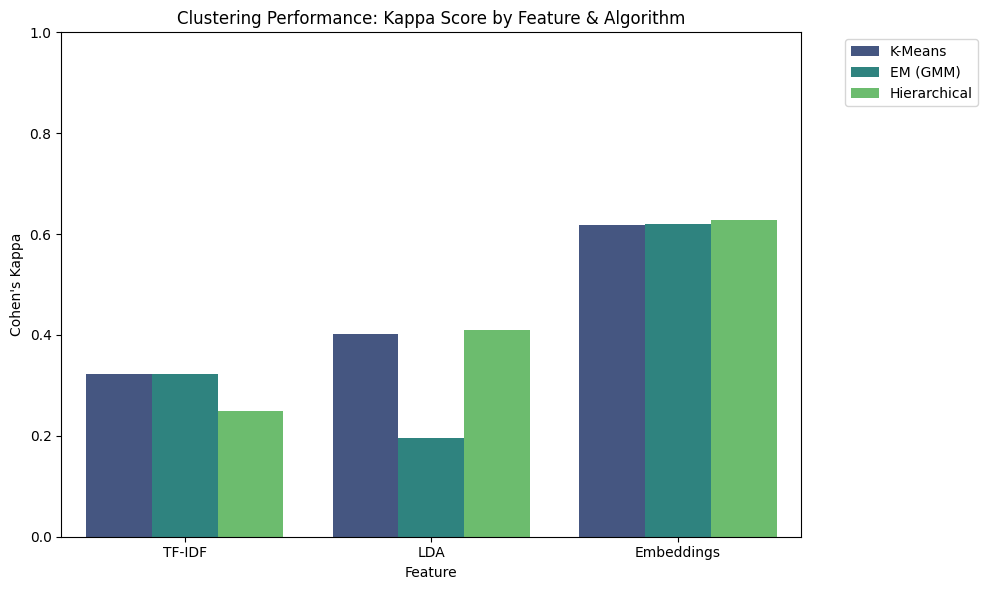

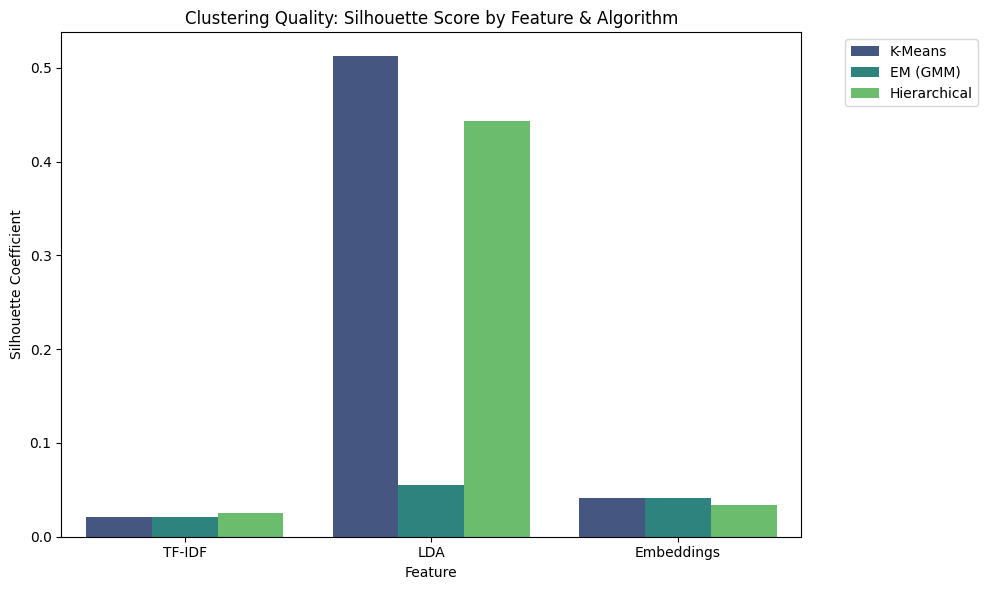

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualization: Kappa Score Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Feature", y="Kappa", hue="Algorithm", palette="viridis")
plt.title("Clustering Performance: Kappa Score by Feature & Algorithm")
plt.ylabel("Cohen's Kappa")
plt.ylim(0, 1) # Kappa is 0 to 1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Visualization: Silhouette Score Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Feature", y="Silhouette", hue="Algorithm", palette="viridis")
plt.title("Clustering Quality: Silhouette Score by Feature & Algorithm")
plt.ylabel("Silhouette Coefficient")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def analyze_errors(X_text, y_true, y_pred, samples_per_genre=2):
    """
    Identifies misclassified samples, extracts characteristics, 
    and prints actual text examples for manual review.
    """
    error_df = pd.DataFrame({"text": X_text, "true": y_true, "predicted": y_pred})
    errors = error_df[error_df['true'] != error_df['predicted']]
    
    print(f"Total Errors Found: {len(errors)}")
    
    # --- Print sample text examples ---
    print(f"\n--- Reviewing {samples_per_genre} Sample Misclassifications Per Genre ---")
    
    for genre in errors['true'].unique():
        genre_errors = errors[errors['true'] == genre]
        
        # Take a sample, or all if less than N
        n = min(samples_per_genre, len(genre_errors))
        sample_subset = genre_errors.sample(n=n, random_state=42)
        
        print(f"\n[Genre: {genre}]")
        for i, row in sample_subset.iterrows():
            print(f"  Predicted: {row['predicted']}")
            print(f"  Snippet: {row['text'][:150]}...")
    
    # --- Existing: Top Characteristics ---
    vec = CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=10)
    error_matrix = vec.fit_transform(errors["text"])
    
    print("\n--- Top 10 Characteristics of Misclassified Instances ---")
    for feature in vec.get_feature_names_out():
        print(f"- {feature}")
        
    return errors

--- CHAMPION MODEL ---
Algorithm: Hierarchical
Feature: Embeddings
Kappa: 0.6273


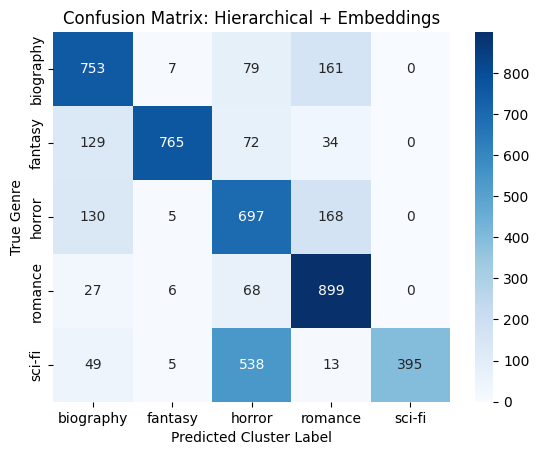

Total Errors Found: 1491

--- Reviewing 2 Sample Misclassifications Per Genre ---

[Genre: biography]
  Predicted: romance
  Snippet: having seen any authentic record containing it. By far the larger part of the slaves know as little of their ages as horses know of theirs, and it is ...
  Predicted: horror
  Snippet: fighting. Their dark-colour'd bodies, half naked, seen only by the gloomy light of the bonfire, running after and beating one another with firebrands,...

[Genre: fantasy]
  Predicted: biography
  Snippet: A continuation of the state of England under Queen Anne. The character of a first minister of state in European courts. My master was yet wholly at a ...
  Predicted: horror
  Snippet: full of meat, which had been provided and sent thither by the king’s orders, upon the first intelligence he received of me. I observed there was the f...

[Genre: horror]
  Predicted: romance
  Snippet: to do with this so terrible affair. It is not good that she run a risk so great. We men

In [9]:
from sklearn.metrics import confusion_matrix

# 1. Find the best model (The Champion)
best_model_idx = results_df['Kappa'].idxmax()
best_model_row = results_df.loc[best_model_idx]

print(f"--- CHAMPION MODEL ---")
print(f"Algorithm: {best_model_row['Algorithm']}")
print(f"Feature: {best_model_row['Feature']}")
print(f"Kappa: {best_model_row['Kappa']:.4f}")

# 2. Re-run that specific model to get the labels again
# (You might need to re-fit or store your predictions during the loop)
# For simplicity, if you didn't store all predictions, you can re-fit:
best_model = models[best_model_row['Algorithm']]
X_best = feature_sets[best_model_row['Feature']]
X_input = X_best.toarray() if hasattr(X_best, "toarray") else X_best

labels_best = best_model.fit_predict(X_input)
mapped_best = map_clusters_to_labels(y, labels_best)

# 3. Create Confusion Matrix for the Champion
cm = confusion_matrix(y, mapped_best, labels=GENRES)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=GENRES, yticklabels=GENRES)
plt.title(f"Confusion Matrix: {best_model_row['Algorithm']} + {best_model_row['Feature']}")
plt.xlabel("Predicted Cluster Label")
plt.ylabel("True Genre")
plt.show()

# 4. Error Analysis for the Champion
misclassified_df = analyze_errors(X_text, y, mapped_best)